In [2]:
import numpy as np
from sim_library.simulation import simulate_pulses_p_dist
from sim_library.constants import k_eff, dR, m, omega_eg, kb, pi
from sim_library.sequences import UpPulse, PulseSequence
import matplotlib.pyplot as plt


In [102]:
N = 10000
Temp = 10e-6

time_steps = 300

rabi_freq = 2*pi*2e5
rabi_time = 2*pi/rabi_freq

pulse_1 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=4*rabi_time)
pulse_seq = PulseSequence()
pulse_seq.add_pulses(pulse_1)
pulse_seq.build_seq()

times = np.linspace(0, 4*rabi_time, time_steps+1)

p_min = 0
p_max = 1
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

beam_profile = np.full(N, 1)
# beam_profile = np.random.uniform(0.9, 1.1, N)
# beam_profile = np.random.normal(loc=1.0, scale=0.2, size=N)

_, _, _, state_fracs1, _ = simulate_pulses_p_dist(pulse_seq=pulse_seq, Temp=Temp, no_atoms=N, basis=basis, initial_state=initial_state, beam_profile=beam_profile)

In [103]:
N = 10000
Temp = 10e-6

time_steps = 300

rabi_freq = 2*pi*2e5
rabi_time = 2*pi/rabi_freq

pulse_1 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=4*rabi_time)
pulse_seq = PulseSequence()
pulse_seq.add_pulses(pulse_1)
pulse_seq.build_seq()

times = np.linspace(0, 4*rabi_time, time_steps+1)

p_min = 0
p_max = 1
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

beam_profile = np.full(N, 1)
# beam_profile = np.random.uniform(0.9, 1.1, N)
beam_profile = np.random.normal(loc=1.0, scale=0.1, size=N)

_, _, _, state_fracs2, _ = simulate_pulses_p_dist(pulse_seq=pulse_seq, Temp=Temp, no_atoms=N, basis=basis, initial_state=initial_state, beam_profile=beam_profile)

In [104]:
print(beam_profile)

[1.1428637  0.991452   1.09187388 ... 0.96148411 0.99924435 0.90562712]


In [105]:
N = 10000
Temp = 10e-6

time_steps = 300

rabi_freq = 2*pi*2e5
rabi_time = 2*pi/rabi_freq

pulse_1 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=4*rabi_time)
pulse_seq = PulseSequence()
pulse_seq.add_pulses(pulse_1)
pulse_seq.build_seq()

times = np.linspace(0, 4*rabi_time, time_steps+1)

p_min = 0
p_max = 1
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

beam_profile = np.full(N, 1)
# beam_profile = np.random.uniform(0.9, 1.1, N)
beam_profile = np.random.normal(loc=1.0, scale=0.2, size=N)

_, _, _, state_fracs3, _ = simulate_pulses_p_dist(pulse_seq=pulse_seq, Temp=Temp, no_atoms=N, basis=basis, initial_state=initial_state, beam_profile=beam_profile)

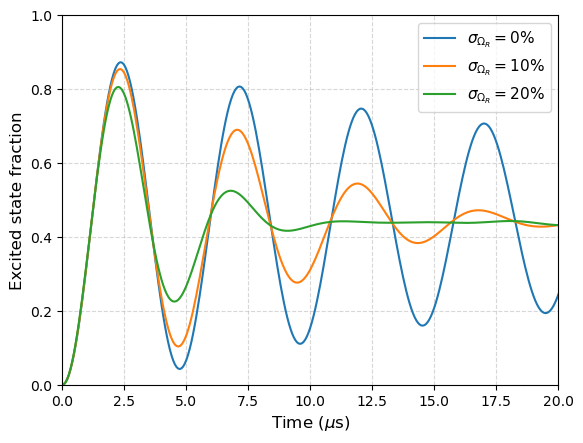

In [129]:
summed = np.sum(state_fracs1, axis=2)
plt.plot(times*1e6, summed[:,1]/N, label= r'$\sigma_{\Omega_R} = 0\%$')
summed = np.sum(state_fracs2, axis=2)
plt.plot(times*1e6, summed[:,1]/N, label = r'$\sigma_{\Omega_R} = 10\%$')
summed = np.sum(state_fracs3, axis=2)
plt.plot(times*1e6, summed[:,1]/N, label  = r'$\sigma_{\Omega_R} = 20\%$')
plt.ylim(0,1)
plt.xlim(times[0]*1e6, times[-1]*1e6)
plt.ylabel('Excited state fraction', fontsize=12)
plt.xlabel(r'Time ($\mu$s)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5, zorder=0)
plt.legend(fontsize=11)
plt.savefig('plots/reports/dephasing1.pdf', format='pdf', bbox_inches='tight')